# Experiments
## RandomAlgorithm experiment

### Read configuration


### Plot RandomAlgorithm Experiment

In [ ]:
# DO NOT RUN THIS CELL - OLD TEST
import matplotlib.pyplot as plt

target_instance = "tai_20_10_0"
instance_df = csv_df[csv_df["Instance"] == target_instance].copy()
if instance_df.empty:
    raise ValueError(f"Instance '{target_instance}' not found in {csv_path.name}.")

best_cost = instance_df["BestCost"].min()
instance_df["RelativeBestCostPct"] = ((instance_df["BestCost"] / best_cost) - 1.0) * 100.0

ax = instance_df.plot(
    x="Evaluations",
    y="RelativeBestCostPct",
    marker="o",
    figsize=(10, 6),
    logx=True,
    legend=False,
    color="#1f77b4",
)

ax.set_xlabel("Sample size")
ax.set_ylabel("Best solution relative to best found [%]")
ax.set_title(f"Relative best solution vs sample size ({target_instance})")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# All algorithm comparison test

## Read algorithm comparison experiment configuration

In [ ]:
from pathlib import Path
import subprocess

from file_io import list_supported_experiment_files, EXPERIMENTS_ROOT, EXPERIMENT_CONFIG_NAME, REPO_ROOT

files = list_supported_experiment_files(EXPERIMENTS_ROOT)
config_path = EXPERIMENTS_ROOT / "tai_all_default_all_algorithms" / EXPERIMENT_CONFIG_NAME

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

repo_root = REPO_ROOT
print("Running:", " ".join(cmd))
result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(result.stdout)
if result.stderr.strip():
    print("STDERR:\n" + result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {result.returncode}")
print("ExperimentRunner finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms\experimentrunner.json
Experiment Runner
Running Random_10000_s12345 on tai_100_10_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_100_20_0...
Running Evolutionary_p100_g100_s12345 on tai_500_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_10_0 (seed 12345)...
Running Random_10000_s12345 on tai_100_20_0 (seed 12345)...
Running Random_10000_s12345 on tai_20_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_5_0 (seed 12345)...
Running Random_10000_s12345 on tai_500_20_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_500_20_0...
Running Evolutionary_p100_g100_s12345 on tai_100_20_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_20_5_0...
Running SimulatedAnn

## Plot all algorithm comparison

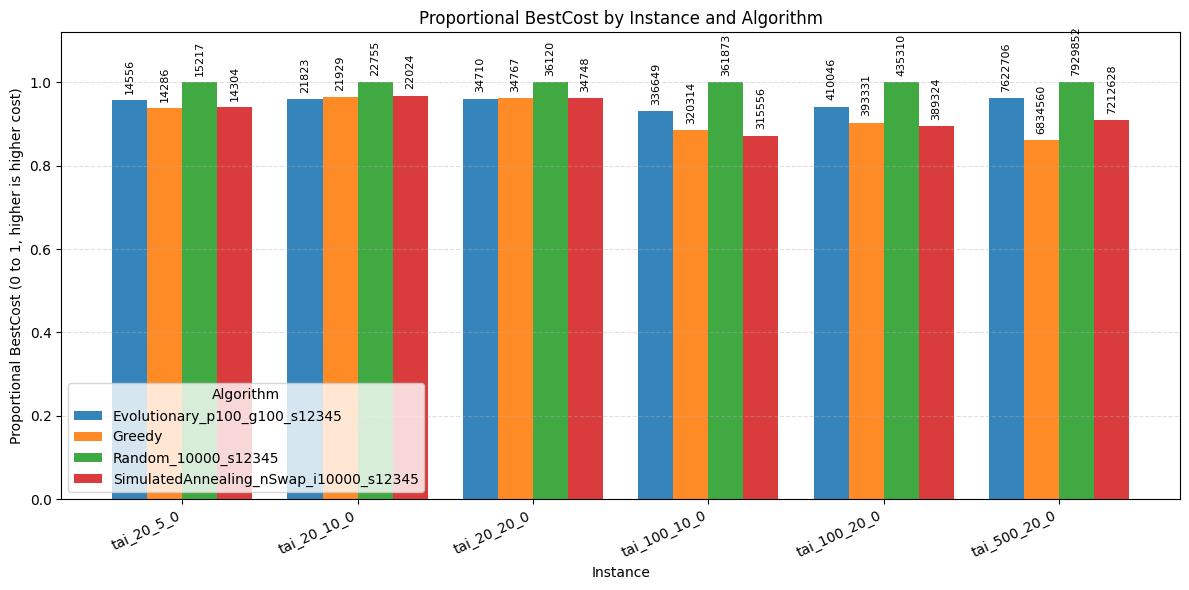

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from file_io import read_csv, find_experiment_results_csv

csv_path = find_experiment_results_csv()
df = read_csv(csv_path)
instance_order = df["Instance"].drop_duplicates().tolist()

pivot = df.pivot_table(
    index="Instance",
    columns="Algorithm",
    values="BestCost",
    aggfunc="min",
)
pivot = pivot.reindex(instance_order)

# Per-instance proportional score in [0, 1]
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

instances = score_pivot.index.to_list()
algorithms = score_pivot.columns.to_list()
x = np.arange(len(instances))
width = 0.8 / max(len(algorithms), 1)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, alg in enumerate(algorithms):
    offset = (idx - (len(algorithms) - 1) / 2) * width
    heights = score_pivot[alg].values
    bars = ax.bar(
        x + offset,
        heights,
        width=width,
        label=alg,
        alpha=0.9,
    )

    # Show BestCost values on bars.
    for bar, cost in zip(bars, pivot[alg].values):
        if pd.notna(cost):
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.015,
                f"{int(cost)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("Proportional BestCost by Instance and Algorithm")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# 2 Parameter Evolutionary test

## Run 2D evolutionary experiment

In [8]:
from file_io import EXPERIMENTS_ROOT, REPO_ROOT
import subprocess
repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "tai_20_5_0_evolutionary_population_generations_2d_256" / "experimentrunner.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(run_result.stdout)
if run_result.stderr.strip():
    print("STDERR:\n" + run_result.stderr)
if run_result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {run_result.returncode}")


Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256\experimentrunner.json
Experiment Runner
Running Evolutionary_p160_g10_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p30_g40_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p30_g60_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p130_g50_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p120_g80_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p70_g40_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p40_g70_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p80_g140_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p50_g10_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p60_g150_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p150_g20_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p70_g30_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p100_g110_s0 on tai_20_5_0 (seed 0)...
Running Evolutio

## Plot 2D Pop/Gen experiment

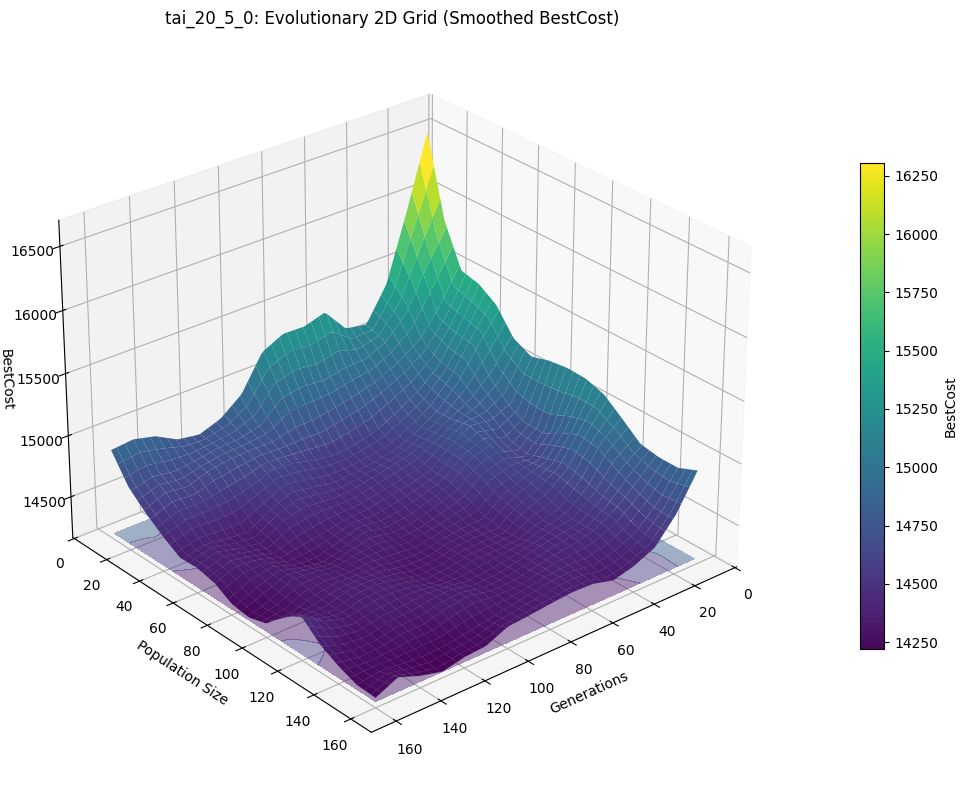

In [10]:
import re

from file_io import EXPERIMENTS_ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = EXPERIMENTS_ROOT / "tai_20_5_0_evolutionary_population_generations_2d_256" / "experiment_results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv}")

df = pd.read_csv(results_csv)
df = df[df["Instance"] == "tai_20_5_0"].copy()

pattern = re.compile(r"Evolutionary_p(?P<p>\d+)_g(?P<g>\d+)_s(?P<s>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["PopulationSize"] = pd.to_numeric(parsed["p"], errors="coerce")
df["Generations"] = pd.to_numeric(parsed["g"], errors="coerce")
df = df.dropna(subset=["PopulationSize", "Generations", "BestCost"]).copy()

df["PopulationSize"] = df["PopulationSize"].astype(int)
df["Generations"] = df["Generations"].astype(int)

surface_df = df.pivot_table(
    index="Generations",
    columns="PopulationSize",
    values="BestCost",
    aggfunc="min",
).sort_index().sort_index(axis=1)

# Optional (install once if needed): pip install scipy
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

# Original regular grid
g_vals = surface_df.index.to_numpy(dtype=float)          # Generations
p_vals = surface_df.columns.to_numpy(dtype=float)        # PopulationSize
Z = surface_df.to_numpy(dtype=float)

# 1) Mild smoothing on original grid
Z_smooth = gaussian_filter(Z, sigma=0.8)

# 2) Upsample to a denser grid for a smoother surface
p_dense = np.linspace(p_vals.min(), p_vals.max(), 120)
g_dense = np.linspace(g_vals.min(), g_vals.max(), 120)
P_dense, G_dense = np.meshgrid(p_dense, g_dense)

interp = RegularGridInterpolator((g_vals, p_vals), Z_smooth, method="linear")
pts = np.column_stack([G_dense.ravel(), P_dense.ravel()])
Z_dense = interp(pts).reshape(G_dense.shape)

# 3D plot (flipped axes: X=Generations, Y=Population Size)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    G_dense,
    P_dense,
    Z_dense,
    cmap="viridis",
    edgecolor="none",      # remove mesh edges for smooth look
    antialiased=True,
    alpha=0.98,
 )

ax.contourf(G_dense, P_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="viridis", alpha=0.45)
ax.set_xlabel("Generations")
ax.set_ylabel("Population Size")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title("tai_20_5_0: Evolutionary 2D Grid (Smoothed BestCost)")
ax.view_init(elev=28, azim=-130)

cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
cbar.set_label("BestCost")
plt.tight_layout()
plt.show()

# SimulatedAnnealing neighbor operators

## Run experiment: all instances × all neighbor operators

In [2]:
import subprocess
from tkinter import E
from file_io import EXPERIMENTS_ROOT, REPO_ROOT

repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "tai_all_default_simulatedannealing_neighbors_seed" / "experimentrunner.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
sa_run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
)

print(sa_run_result.stdout)
if sa_run_result.stderr.strip():
    print("STDERR:\n" + sa_run_result.stderr)
if sa_run_result.returncode != 0:
    raise RuntimeError(
        f"ExperimentRunner failed with exit code {sa_run_result.returncode}"
    )

print("SimulatedAnnealing neighbor experiment finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed\experimentrunner.json
C:\Users\szymo\source\repos\CichySA\Optimization_methods\PFSP\Algorithms\SimulatedAnnealing\SimulatedAnnealingParameterFactory.cs(119,31): warning CS8634: The type 'PFSP.Algorithms.SimulatedAnnealing.Operators.ICoolingSchedule?' cannot be used as type parameter 'T' in the generic type or method 'SimulatedAnnealingParameterFactory.ResolveOperatorName<T>(T, Dictionary<string, Func<T>>)'. Nullability of type argument 'PFSP.Algorithms.SimulatedAnnealing.Operators.ICoolingSchedule?' doesn't match 'class' constraint. [C:\Users\szymo\source\repos\CichySA\Optimization_methods\PFSP\PFSP.csproj]
C:\Users\szymo\source\repos\CichySA\Optimization_methods\PFSP\Algorithms\SimulatedAnnealing\SimulatedAnnealingParameterFactory.cs(119,70): warning CS8620: Argument of type 'Dictionary<string, Func<ICoolingSc

## Plot SA neighbor operator comparison

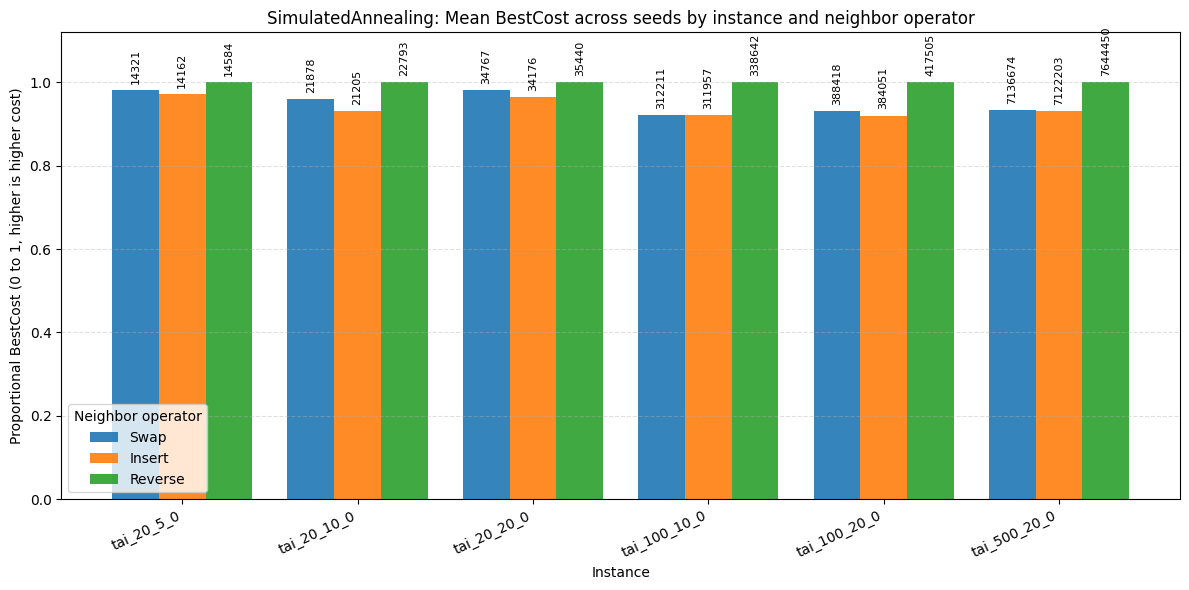

Neighbor,Swap,Insert,Reverse
Instance,,,
tai_20_5_0,0.982008,0.971106,1.0
tai_20_10_0,0.959891,0.930347,1.0
tai_20_20_0,0.980994,0.964335,1.0
tai_100_10_0,0.921952,0.921202,1.0
tai_100_20_0,0.930331,0.919871,1.0
tai_500_20_0,0.933576,0.931683,1.0


In [3]:
import re
from file_io import EXPERIMENTS_ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = EXPERIMENTS_ROOT / "tai_all_default_simulatedannealing_neighbors_seed" / "experiment_results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv.resolve()}")

# Read full results
df = pd.read_csv(results_csv)

# Parse NeighborhoodOperator and Seed from algorithm name: SimulatedAnnealing_n{Neighbor}_i{Iters}_s{Seed}
pattern = re.compile(r"SimulatedAnnealing_n(?P<Neighbor>[^_]+)_i\d+_s(?P<Seed>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["Neighbor"] = parsed["Neighbor"]
df["Seed"] = pd.to_numeric(parsed["Seed"], errors="coerce")
df = df.dropna(subset=["Neighbor", "BestCost", "Seed"]).copy()

instance_order = df["Instance"].drop_duplicates().tolist()
operator_order = ["Swap", "Insert", "Reverse"]

# For each Instance x Neighbor x Seed take the best (min) BestCost, then average across seeds
mean_by_seed = df.groupby(["Instance", "Neighbor"], as_index=False)["BestCost"].mean()
pivot = mean_by_seed.pivot(index="Instance", columns="Neighbor", values="BestCost").reindex(index=instance_order, columns=operator_order)

# Per-instance proportional score in [0, 1] computed from averaged BestCost across seeds
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

x = np.arange(len(instance_order))
width = 0.8 / len(operator_order)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 6))
for idx, op in enumerate(operator_order):
    offset = (idx - (len(operator_order) - 1) / 2) * width
    heights = score_pivot[op].values
    bars = ax.bar(x + offset, heights, width=width, label=op,
                  alpha=0.9, color=colors[idx])

    for bar, val in zip(bars, pivot[op].values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{int(val)}",
                ha="center", va="bottom", fontsize=8, rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instance_order, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("SimulatedAnnealing: Mean BestCost across seeds by instance and neighbor operator")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Neighbor operator")
plt.tight_layout()
plt.show()

score_pivot

# TODOS

## General
* EA and SA additional heuristics
* Restart and barrier breaking
* IRACE?
* Measurement and metadata plug-in

## Experiment
* Generalize runner configuration even more
* DTO unification and cross-program setup
* Test averaging
* Algorithm runtime metadata - not only
* Ablation and other extras

## EA
* Implement different Mutation and Crossover operators
* Start from heuristic solution
* Roulette
* Fitness penalty

# SA
* Cooling schedule comparison

# Fix
* NEH running time
* Missing Random evals and test run
* Make sure Greedy runs once!

# Questions
* Problem formulation
* Should I also optimize SA?
* Computation load, stop conditions, stuck

In [42]:
from file_io import EXPERIMENTS_ROOT, REPO_ROOT
import subprocess
repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "monitor_every_event_example" / "experimentrunner.json"
if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")
cmd = ["dotnet", "run", "--project", "ExperimentRunner", "--", "--config", str(config_path)]
print("Running:", " ".join(cmd))
run_result = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True, check=False)
print(run_result.stdout)
if run_result.stderr.strip():
    print("STDERR:\n" + run_result.stderr)
if run_result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {run_result.returncode}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example\experimentrunner.json
Experiment Runner
Running Evolutionary_p100_g100_s7004243 on tai_20_5_0 (seed 7004243)...
Running Evolutionary_p100_g100_s13004261 on tai_20_5_0 (seed 13004261)...
Running Evolutionary_p100_g100_s25004297 on tai_20_5_0 (seed 25004297)...
Running Evolutionary_p100_g100_s15004267 on tai_20_5_0 (seed 15004267)...
Running Evolutionary_p100_g100_s18004276 on tai_20_5_0 (seed 18004276)...
Running Evolutionary_p100_g100_s2004228 on tai_20_5_0 (seed 2004228)...
Running Evolutionary_p100_g100_s4004234 on tai_20_5_0 (seed 4004234)...
Running Evolutionary_p100_g100_s16004270 on tai_20_5_0 (seed 16004270)...
Running Evolutionary_p100_g100_s6004240 on tai_20_5_0 (seed 6004240)...
Running Evolutionary_p100_g100_s24004294 on tai_20_5_0 (seed 24004294)...
Running Evolutionary_p100_g100_s28004306 on tai_20_5_0 (seed 28004306)..

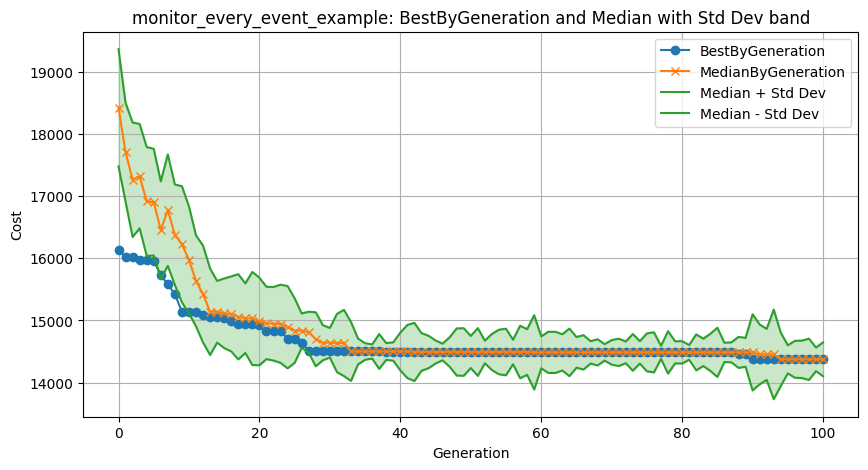

{'BestByGeneration': [16135.0,
  16022.0,
  16022.0,
  15975.0,
  15975.0,
  15963.0,
  15728.0,
  15579.0,
  15423.0,
  15139.0,
  15139.0,
  15139.0,
  15094.0,
  15058.0,
  15058.0,
  15031.0,
  14983.0,
  14937.0,
  14937.0,
  14937.0,
  14926.0,
  14836.0,
  14836.0,
  14836.0,
  14696.0,
  14696.0,
  14641.0,
  14512.0,
  14512.0,
  14512.0,
  14512.0,
  14500.0,
  14500.0,
  14500.0,
  14500.0,
  14500.0,
  14500.0,
  14500.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14492.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14486.0,
  14453.0,
 

In [43]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from file_io import EXPERIMENTS_ROOT

out_dir = EXPERIMENTS_ROOT / "monitor_every_event_example"
results_csv = out_dir / "experiment_results.csv"
detailed_json = out_dir / "experiment_results.json"

if not results_csv.exists() and not detailed_json.exists():
    raise FileNotFoundError(f"No results found in {out_dir}. Run the experiment first.")

if detailed_json.exists():
    with open(detailed_json, 'r') as f:
        details = json.load(f)
    if not details:
        raise RuntimeError("Detailed results JSON is empty.")

    exp = details[0]
    metrics = exp.get('Metrics') or exp.get('ExperimentalData') or {}
    best_by_gen = metrics.get('BestByGeneration')
    median_by_gen = metrics.get('MedianByGeneration')
    deviation_by_gen = metrics.get('DeviationByGeneration')

    s_best = pd.Series(best_by_gen) if best_by_gen is not None else None
    s_median = pd.Series(median_by_gen) if median_by_gen is not None else None
    s_std = pd.Series(deviation_by_gen) if deviation_by_gen is not None else None

    plt.figure(figsize=(10, 5))

    if s_best is not None:
        s_best.plot(marker='o', label='BestByGeneration', color='C0')

    if s_median is not None:
        s_median.plot(marker='x', label='MedianByGeneration', color='C1')

    if s_median is not None and s_std is not None:
        n = min(len(s_median), len(s_std))
        s_median = s_median.iloc[:n]
        s_std = s_std.iloc[:n]

        upper = s_median + s_std
        lower = s_median - s_std
        x = s_median.index

        upper.plot(label='Median + Std Dev', color='C2', linestyle='-')
        lower.plot(label='Median - Std Dev', color='C2', linestyle='-')
        plt.fill_between(x, lower.values, upper.values, color='C2', alpha=0.25)

    plt.xlabel('Generation')
    plt.ylabel('Cost')
    plt.title('monitor_every_event_example: BestByGeneration and Median with Std Dev band')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    # Fallback: try plotting any numeric columns present in CSV that resemble the metrics
    df = pd.read_csv(results_csv)
    print('Available CSV columns:', df.columns.tolist())
    raise RuntimeError('Detailed experimental metrics not found in JSON; check output configuration to save detailed results.')

metrics

In [64]:
from file_io import EXPERIMENTS_ROOT, REPO_ROOT
import subprocess
repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "monitor_every_event_example_2D" / "experimentrunner.json"
if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")
cmd = ["dotnet", "run", "--project", "ExperimentRunner", "--", "--config", str(config_path)]
print("Running:", " ".join(cmd))
run_result = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True, check=False)
print(run_result.stdout)
if run_result.stderr.strip():
    print("STDERR:\n" + run_result.stderr)
if run_result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {run_result.returncode}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example_2D\experimentrunner.json
Experiment Runner
Running Evolutionary_p100_g100_s6004240 on tai_20_5_0 (seed 6004240)...
Running Evolutionary_p100_g100_s14004264 on tai_20_5_0 (seed 14004264)...
Running Evolutionary_p100_g100_s4004234 on tai_20_5_0 (seed 4004234)...
Running Evolutionary_p100_g100_s17004273 on tai_20_5_0 (seed 17004273)...
Running Evolutionary_p100_g100_s20004282 on tai_20_5_0 (seed 20004282)...
Running Evolutionary_p100_g100_s9004249 on tai_20_5_0 (seed 9004249)...
Running Evolutionary_p100_g100_s25004297 on tai_20_5_0 (seed 25004297)...
Running Evolutionary_p100_g100_s23004291 on tai_20_5_0 (seed 23004291)...
Running Evolutionary_p100_g100_s29004309 on tai_20_5_0 (seed 29004309)...
Running Evolutionary_p100_g100_s28004306 on tai_20_5_0 (seed 28004306)...
Running Evolutionary_p100_g100_s24004294 on tai_20_5_0 (seed 240042

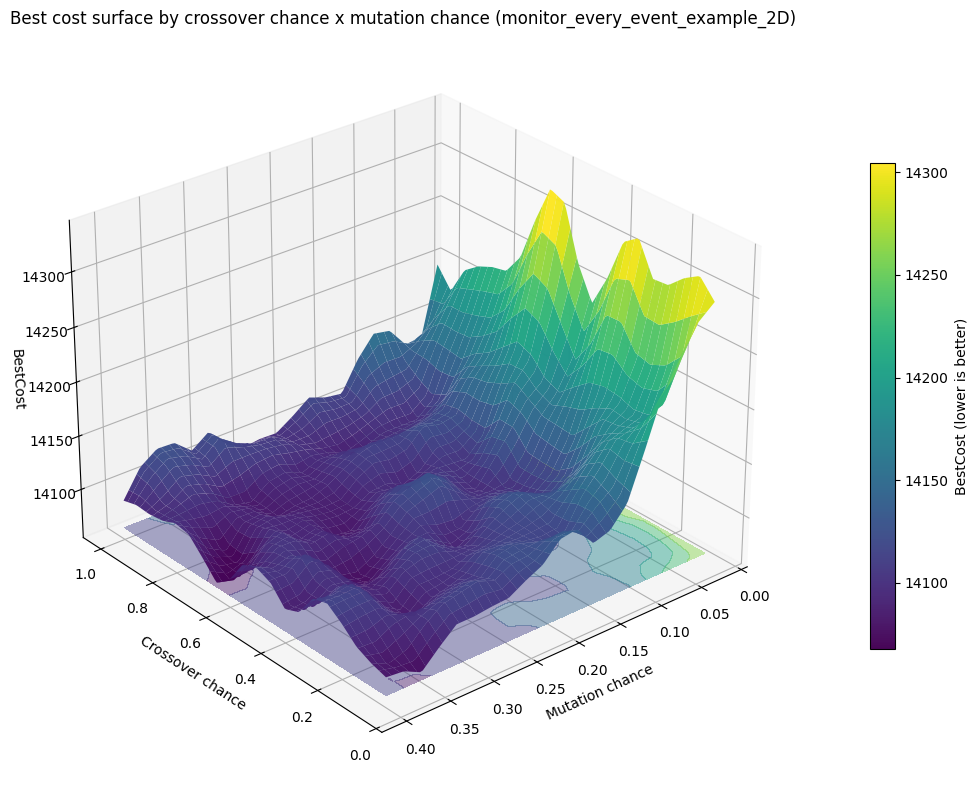

MutationRate,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22,0.24,0.26,0.28,0.30,0.32,0.34,0.36,0.38,0.40
CrossoverRate,,,,,,,,,,,,,,,,,,,,
0.05,14261.0,14340.0,14293.0,14252.0,14196.0,14123.0,14125.0,14083.0,14169.0,14143.0,14119.0,14110.0,14092.0,14090.0,14085.0,14101.0,14090.0,14034.0,14112.0,14070.0
0.10,14407.0,14152.0,14144.0,14227.0,14163.0,14129.0,14170.0,14127.0,14153.0,14142.0,14083.0,14164.0,14098.0,14176.0,14119.0,14140.0,14103.0,14091.0,14043.0,14103.0
0.15,14322.0,14207.0,14202.0,14155.0,14231.0,14144.0,14188.0,14060.0,14095.0,14100.0,14166.0,14118.0,14069.0,14116.0,14097.0,14110.0,14107.0,14124.0,14080.0,14089.0
0.20,14352.0,14175.0,14170.0,14171.0,14184.0,14158.0,14123.0,14107.0,14150.0,14121.0,14083.0,14157.0,14111.0,14090.0,14090.0,14052.0,14086.0,14104.0,14118.0,14104.0
0.25,14271.0,14191.0,14188.0,14230.0,14092.0,14156.0,14115.0,14146.0,14083.0,14111.0,14114.0,14085.0,14085.0,14072.0,14147.0,14042.0,14092.0,14144.0,14110.0,14119.0
0.30,14412.0,14222.0,14172.0,14179.0,14115.0,14088.0,14126.0,14154.0,14119.0,14147.0,14085.0,14120.0,14116.0,14123.0,14110.0,14108.0,14070.0,14152.0,14097.0,14133.0
0.35,14323.0,14268.0,14192.0,14096.0,14117.0,14094.0,14119.0,14111.0,14161.0,14074.0,14077.0,14059.0,14158.0,14118.0,14091.0,14077.0,14100.0,14104.0,14064.0,14088.0
0.40,14322.0,14165.0,14202.0,14147.0,14128.0,14099.0,14114.0,14105.0,14097.0,14043.0,14093.0,14154.0,14060.0,14099.0,14064.0,14063.0,14117.0,14083.0,14076.0,14069.0
0.45,14234.0,14111.0,14177.0,14153.0,14101.0,14033.0,14136.0,14088.0,14096.0,14180.0,14107.0,14110.0,14095.0,14060.0,14048.0,14076.0,14110.0,14186.0,14085.0,14123.0


In [ ]:
import json

from file_io import EXPERIMENTS_ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_json = EXPERIMENTS_ROOT / "monitor_every_event_example_2D" / "experiment_results.json"
if not results_json.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_json}")

with open(results_json, "r") as f:
    data = json.load(f)

rows = []
for run in data:
    parameters = run.get("Parameters") or {}
    best = run.get("Best") or {}

    crossover_rate = parameters.get("CrossoverRate")
    mutation_rate = parameters.get("MutationRate")
    best_cost = best.get("Cost")

    if crossover_rate is None or mutation_rate is None or best_cost is None:
        continue

    rows.append(
        {
            "CrossoverRate": float(crossover_rate),
            "MutationRate": float(mutation_rate),
            "BestCost": float(best_cost),
        }
    )

if not rows:
    raise RuntimeError("No valid rows found with CrossoverRate, MutationRate, and Best.Cost.")

df = pd.DataFrame(rows)

# Best (minimum) result for each crossover x mutation combination.
best_by_combo = (
    df.groupby(["CrossoverRate", "MutationRate"], as_index=False)["BestCost"]
    .min()
)
best_by_combo = (
    df.groupby(["CrossoverRate", "MutationRate"], as_index=False)["BestCost"]
    .mean()
)
surface_df = (
    best_by_combo
    .pivot(index="CrossoverRate", columns="MutationRate", values="BestCost")
    .sort_index()
    .sort_index(axis=1)
)

y_vals = surface_df.index.to_numpy(dtype=float)      # Crossover chance
x_vals = surface_df.columns.to_numpy(dtype=float)    # Mutation chance
Z = surface_df.to_numpy(dtype=float)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# A proper surface needs at least a 2x2 grid. If there is only one combo,
# fall back to a 3D point while keeping the same axis semantics.
if Z.shape[0] >= 2 and Z.shape[1] >= 2 and not np.isnan(Z).any():
    # Optional smoothing + upsampling like cell 11.
    try:
        from scipy.interpolate import RegularGridInterpolator
        from scipy.ndimage import gaussian_filter

        Z_smooth = gaussian_filter(Z, sigma=0.8)

        x_dense = np.linspace(x_vals.min(), x_vals.max(), 120)
        y_dense = np.linspace(y_vals.min(), y_vals.max(), 120)
        X_dense, Y_dense = np.meshgrid(x_dense, y_dense)

        interp = RegularGridInterpolator((y_vals, x_vals), Z_smooth, method="linear")
        pts = np.column_stack([Y_dense.ravel(), X_dense.ravel()])
        Z_dense = interp(pts).reshape(Y_dense.shape)

        surf = ax.plot_surface(
            X_dense,
            Y_dense,
            Z_dense,
            cmap="viridis",
            edgecolor="none",
            antialiased=True,
            alpha=0.98,
        )
        ax.contourf(X_dense, Y_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="viridis", alpha=0.45)
    except Exception:
        X, Y = np.meshgrid(x_vals, y_vals)
        surf = ax.plot_surface(
            X,
            Y,
            Z,
            cmap="viridis",
            edgecolor="none",
            antialiased=True,
            alpha=0.98,
        )
        ax.contourf(X, Y, Z, zdir="z", offset=np.nanmin(Z), cmap="viridis", alpha=0.45)

    cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
    cbar.set_label("BestCost (lower is better)")
else:
    x0 = x_vals[0]
    y0 = y_vals[0]
    z0 = float(Z[0, 0])
    ax.scatter([x0], [y0], [z0], color="#ff7f0e", s=80)
    ax.text(x0, y0, z0, f" {int(z0)}", color="black")

ax.set_xlabel("Mutation chance")
ax.set_ylabel("Crossover chance")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.set_title("Best cost surface by crossover chance x mutation chance (monitor_every_event_example_2D)")
ax.view_init(elev=28, azim=-130)

plt.tight_layout()
plt.show()

surface_df